In [6]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [7]:
from __future__ import annotations
import operator
from typing import TypedDict, List, Annotated, Literal, Optional

In [8]:
from dotenv import load_dotenv

In [9]:
from pathlib import Path
from langchain_community.tools.tavily_search import TavilySearchResults

In [10]:
load_dotenv()

True

## Task Model

In [11]:
class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ...,
        description='One sentence describing what the reader should be able to do/understand after this section.'
    )
    bullets: List[str] = Field(
        ...,
        min_length = 3,
        max_length = 5,
        description = '3-5 concrete, non-overlapping subpoints ot cover this section.'
    )
    target_words : int = Field(
        ...,
        description = 'Target word count for this section (12-450).'
    )
    tags: List[str] = Field(default_factory=list)
    requires_research:bool = False
    requires_citation: bool = False
    requires_code:bool = False

In [12]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal['explainer', 'tutorial', 'news_roundup', 'comparison', 'system_design'] = 'explainer'
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

In [13]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at : Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

In [15]:
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal['closed_book', 'hybrd', 'open_book']
    queries: List[str] = Field(default_factory=list)

In [16]:
class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [17]:
llm = ChatOpenAI(model = 'gpt-4o')

In [18]:
class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str

In [ ]:
def orchestrator(state: State) -> dict:
    planner = llm.with_structured_output(Plan)
    plan = planner.invoke(
        [
            SystemMessage(
                content = (
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."                    
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}")
        ]
    )

    return {"plan": plan}

In [ ]:
def fanout(state:State):
    return [
        Send(
            'worker', 
            {'task':task, "topic": state['topic'], "plan": state['plan']}
            ) 
            for task in state['plan'].tasks
    ]

In [ ]:
def worker(payload: dict) -> dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()
    return {"sections": [section_md]}

In [ ]:
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [ ]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node('worker', worker)
g.add_node('reducer', reducer)

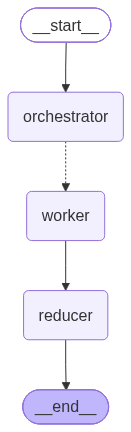

In [ ]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges('orchestrator', fanout, ['worker'])
g.add_edge('worker', "reducer")
g.add_edge('reducer', END)

app = g.compile()
app

In [ ]:
output = app.invoke({"topic": "Write a blog on Transformer", "sections":[]})

In [ ]:
output

{'topic': 'Write a blog on Transformer',
 'plan': Plan(blog_title='Mastering Transformers: Unraveling the Magic Behind NLP', audience='Developers and Data Scientists interested in Natural Language Processing', tone='Practical and comprehensive', tasks=[Task(id=1, title='Introduction to Transformers', goal='Understand the evolution and significance of Transformer models in NLP.', bullets=['Provide a brief history of NLP models leading up to Transformers.', 'Explain the limitations of previous sequence-based models like RNNs and LSTMs.', 'Introduce the concept of attention and how Transformers make use of it.', "Highlight key contributions of the original Transformer paper, 'Attention is All You Need.'"], target_words=150, section_type='intro'), Task(id=2, title='Self-Attention Mechanism', goal='Comprehend how self-attention mechanisms work within the Transformer architecture.', bullets=['Describe the self-attention mechanism and its role in capturing dependencies between words in a sent